In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from config import (
    FORWARD_MODEL_PATH, BACKWARD_MODEL_PATH,
    FORWARD_HISTORY_PATH, TANDEM_HISTORY_PATH, CHECKPOINT_DIR
)
from data_loader import prepare_data, load_normalizers
from models import ForwardNet, BackwardNet, TandemNet
from utils import get_device

In [2]:
import pandas as pd

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if TANDEM_HISTORY_PATH.exists():
    history = np.load(TANDEM_HISTORY_PATH, allow_pickle=True).item()
    ax = axes[1]
    epochs = range(1, len(history['train_loss']) + 1)
    ax.plot(epochs, history['train_loss'], label='Train Loss')
    ax.plot(epochs, history['test_loss'], label='Test Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.set_title('Tandem Network Training History')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

data = {
    'epoch': range(1, len(history['train_loss']) + 1),
    'train_loss': history['train_loss'],
    'test_loss': history['test_loss']
}

# 2. 转换为 DataFrame
df = pd.DataFrame(data)

# 3. 保存为 CSV
df.to_csv('training_history.csv', index=False)
print("保存成功！")

推理器初始化完成。使用设备: cuda

正在对以下参数进行推理:
[[9.5e-08 7.4e-08 2.4e-08]
 [6.0e-08 1.5e-07 3.0e-08]]

预测完成! 光谱形状: (2, 200)
光谱数据范围: [0.0346, 0.7987]


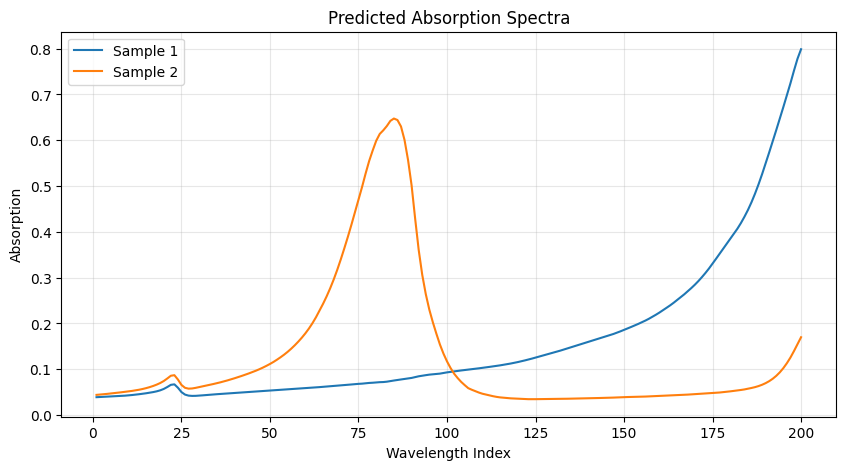

In [4]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# 导入项目中已有的模块
from config import (
    FORWARD_MODEL_PATH, 
    PARAMS_NORMALIZER_PATH, 
    SPECTRA_NORMALIZER_PATH,
    FORWARD_CONFIG
)
from models import ForwardNet
from data_loader import ZScoreNormalizer, MinMaxNormalizer
from utils import get_device

class ForwardPredictor:
    """
    封装前向网络推理流程：
    自动处理 模型加载 + 输入标准化 + 输出反归一化
    """
    def __init__(self, model_path=None):
        self.device = get_device()
        self.model_path = model_path or FORWARD_MODEL_PATH
        
        # 1. 初始化并加载模型
        self.model = self._load_model()
        
        # 2. 加载数据标准化器 (必须与训练时一致)
        self.params_normalizer = ZScoreNormalizer()
        self.params_normalizer.load(PARAMS_NORMALIZER_PATH)
        
        self.spectra_normalizer = MinMaxNormalizer()
        self.spectra_normalizer.load(SPECTRA_NORMALIZER_PATH)
        
        print(f"推理器初始化完成。使用设备: {self.device}")

    def _load_model(self):
        """加载训练好的前向网络权重"""
        if not Path(self.model_path).exists():
            raise FileNotFoundError(f"找不到模型文件: {self.model_path}")
            
        model = ForwardNet(config=FORWARD_CONFIG).to(self.device)
        checkpoint = torch.load(self.model_path, map_location=self.device)
        model.load_state_dict(checkpoint['model_state_dict'])
        model.eval()  # 切换到评估模式 (关闭 Dropout, 锁定 BN)
        return model

    @torch.no_grad()
    def predict(self, raw_params):
        """
        对新的原始结构参数进行推理
        
        Args:
            raw_params (list or np.array): 形状为 (N, 3) 或 (3,) 的原始参数
            
        Returns:
            np.array: 预测的真实光谱数据，形状为 (N, 200)
        """
        # 确保输入是 2D numpy 数组 (N, 3)
        raw_params = np.array(raw_params)
        if raw_params.ndim == 1:
            raw_params = raw_params[np.newaxis, :]
            
        # 1. 预处理：对输入参数进行 Z-Score 标准化
        #
        norm_params = self.params_normalizer.transform(raw_params)
        
        # 2. 转换为 Tensor 并移动到设备
        input_tensor = torch.from_numpy(norm_params).float().to(self.device)
        
        # 3. 模型推理
        norm_spectra_pred = self.model(input_tensor)
        
        # 4. 转回 Numpy
        norm_spectra_pred = norm_spectra_pred.cpu().numpy()
        
        # 5. 后处理：对输出光谱进行反归一化 (Min-Max Inverse)
        #
        real_spectra_pred = self.spectra_normalizer.inverse_transform(norm_spectra_pred)
        
        return real_spectra_pred

def visualize_result(spectra, save_path="prediction.png"):
    """简单的可视化函数"""
    plt.figure(figsize=(10, 5))
    wavelengths = np.arange(1, spectra.shape[1] + 1)
    
    for i in range(len(spectra)):
        plt.plot(wavelengths, spectra[i], label=f'Sample {i+1}')
        
    plt.title("Predicted Absorption Spectra")
    plt.xlabel("Wavelength Index")
    plt.ylabel("Absorption")
    plt.grid(True, alpha=0.3)
    plt.legend()
    # plt.savefig(save_path)
    # print(f"结果图已保存至: {save_path}")
    plt.show()

# ================= 使用示例 =================
if __name__ == "__main__":
    # 1. 实例化推理器
    predictor = ForwardPredictor()
    
    # 2. 定义新的输入参数 (这里假设有两组新参数)
    # 注意：这里的数值应该是真实的物理量，不需要手动标准化
    new_params = [
        [95e-9, 74e-9, 24e-9],  # 样本 1
        [60e-9, 150e-9, 30e-9]   # 样本 2
    ]
    
    print(f"\n正在对以下参数进行推理:\n{np.array(new_params)}")
    
    # 3. 执行推理
    predicted_spectra = predictor.predict(new_params)
    
    print(f"\n预测完成! 光谱形状: {predicted_spectra.shape}")
    print(f"光谱数据范围: [{predicted_spectra.min():.4f}, {predicted_spectra.max():.4f}]")
    
    # 4. 可视化结果
    visualize_result(predicted_spectra)

In [5]:
predicted_spectra.shape

(2, 200)

In [69]:
# 2. 转换为 DataFrame
df = pd.DataFrame(predicted_spectra)

# 3. 保存为 CSV
df.to_csv('forward.csv', index=False)

In [10]:
# 逆向推理

import torch
import numpy as np
import pandas as pd
from pathlib import Path

# 导入项目中已有的模块
from config import (
    BACKWARD_MODEL_PATH, 
    PARAMS_NORMALIZER_PATH, 
    SPECTRA_NORMALIZER_PATH,
    BACKWARD_CONFIG
)
from models import BackwardNet
from data_loader import ZScoreNormalizer, MinMaxNormalizer
from utils import get_device

class BackwardPredictor:
    """
    封装反向网络（逆向设计）推理流程：
    输入目标光谱 -> 标准化 -> 模型推理 -> 参数反归一化 -> 输出结构参数
    """
    def __init__(self, model_path=None):
        self.device = get_device()
        self.model_path = model_path or BACKWARD_MODEL_PATH
        
        # 1. 初始化并加载模型
        self.model = self._load_model()
        
        # 2. 加载数据标准化器
        # 注意：在反向网络中，光谱是输入，参数是输出
        
        # 输入端：光谱标准化器 (Min-Max)
        self.spectra_normalizer = MinMaxNormalizer()
        self.spectra_normalizer.load(SPECTRA_NORMALIZER_PATH)
        
        # 输出端：参数标准化器 (Z-Score)
        self.params_normalizer = ZScoreNormalizer()
        self.params_normalizer.load(PARAMS_NORMALIZER_PATH)
        
        print(f"逆向设计推理器初始化完成。使用设备: {self.device}")

    def _load_model(self):
        """加载训练好的后向网络权重"""
        if not Path(self.model_path).exists():
            raise FileNotFoundError(f"找不到模型文件: {self.model_path}")
            
        # 初始化模型结构
        model = BackwardNet(config=BACKWARD_CONFIG).to(self.device)
        
        # 加载权重
        checkpoint = torch.load(self.model_path, map_location=self.device)
        model.load_state_dict(checkpoint['model_state_dict'])
        model.eval()
        return model

    @torch.no_grad()
    def predict(self, raw_spectra):
        """
        根据目标光谱反推结构参数
        
        Args:
            raw_spectra (list or np.array): 形状为 (N, 200) 或 (200,) 的原始光谱数据
            
        Returns:
            np.array: 预测的真实结构参数，形状为 (N, 3)
        """
        # 确保输入是 2D numpy 数组
        raw_spectra = np.array(raw_spectra)
        if raw_spectra.ndim == 1:
            raw_spectra = raw_spectra[np.newaxis, :]
            
        # 1. 预处理：对输入光谱进行 Min-Max 标准化
        #
        norm_spectra = self.spectra_normalizer.transform(raw_spectra)
        
        # 2. 转换为 Tensor 并移动到设备
        input_tensor = torch.from_numpy(norm_spectra).float().to(self.device)
        
        # 3. 模型推理 (得到归一化的参数)
        norm_params_pred = self.model(input_tensor)
        
        # 4. 转回 Numpy
        norm_params_pred = norm_params_pred.cpu().numpy()
        
        # 5. 后处理：对输出参数进行反归一化 (Z-Score Inverse)
        #
        real_params_pred = self.params_normalizer.inverse_transform(norm_params_pred)
        
        return real_params_pred

def save_inverse_design_results(target_spectra, predicted_params, filename="inverse_design_results.csv"):
    """
    保存逆向设计结果：目标光谱 + 预测参数
    """
    # 1. 处理光谱部分 (Input)
    spectrum_cols = [f"Target_Wave_{i+1}" for i in range(target_spectra.shape[1])]
    df_spectra = pd.DataFrame(target_spectra, columns=spectrum_cols)
    
    # 2. 处理参数部分 (Output)
    # 假设有3个结构参数
    param_cols = ["Pred_Param_1", "Pred_Param_2", "Pred_Param_3"]
    df_params = pd.DataFrame(predicted_params, columns=param_cols)
    
    # 3. 合并数据：通常把预测结果放在前面比较直观
    df_final = pd.concat([df_params, df_spectra], axis=1)
    
    df_final.index.name = "Design_ID"
    df_final.to_csv(filename)
    print(f"逆向设计结果已保存至: {filename}")

# ================= 使用示例 =================
if __name__ == "__main__":
    # 1. 实例化推理器
    predictor = BackwardPredictor()
    
    # 2. 生成模拟的目标光谱数据
    # 实际使用时，这里应该是您想要实现的真实光谱目标
    # 例如：生成两个随机光谱用于测试
    dummy_spectra = pd.read_csv('data_inverse.csv', header=None).iloc[:, 1].values.reshape(1, -1)
    
    print(f"\n正在对 {len(dummy_spectra)} 组目标光谱进行逆向设计...")
    
    # 3. 执行推理
    predicted_params = predictor.predict(dummy_spectra)
    
    print(f"\n推理完成!")
    print(f"预测参数形状: {predicted_params.shape}")
    
    # 打印前几个结果
    for i, params in enumerate(predicted_params):
        print(f"设计 {i+1} 推荐参数: {params}")
        
    # 4. 保存结果
    save_inverse_design_results(dummy_spectra, predicted_params)

逆向设计推理器初始化完成。使用设备: cuda

正在对 1 组目标光谱进行逆向设计...

推理完成!
预测参数形状: (1, 3)
设计 1 推荐参数: [2.4468943e-07 9.8097807e-08 3.5966814e-08]
逆向设计结果已保存至: inverse_design_results.csv
